In [9]:
%pip install ray
%pip install gradio
%pip install "ray[tune]" pyarrow


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 63.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import multiprocessing
from multiprocessing import reduction
import subprocess
from pathlib import Path
import json

from dotenv import load_dotenv
load_dotenv()

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from torch.utils.data import Dataset, DataLoader
import torch

from ray import tune
import ray
from ray import train as ray_train

import umap

import gradio as gr

2026-05-05 18:13:46,874	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [11]:
DATASET_SLUG = "alexteboul/english-premier-league-logo-detection-20k-images"
DATA_DIR = Path("data")
LOGOS_DIR = DATA_DIR / "epl-logos-big" / "epl-logos-big"
OUTPUT_PATH = Path("preprocessed_imgs").resolve()
IMG_SIZE = 128

## Image Loading and Processing

In [12]:
def download_dataset():
    if LOGOS_DIR.exists():
        print(f"Dataset already present at '{LOGOS_DIR}'. Skipping download.")
        return

    DATA_DIR.mkdir(exist_ok=True)
    print("Downloading dataset from Kaggle...")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", DATASET_SLUG,
         "--unzip", "-p", str(DATA_DIR)],
        check=True,
    )
    print("Download complete.")

In [13]:
def collect_image_paths(logos_dir: Path) -> list[tuple[Path, str]]:
    # Return a flat list of (image_path, team_name) tuples for every image
    team_image_paths = []
    # Loop through the logo directory in alpha order
    for team_dir in sorted(logos_dir.iterdir()):
        # Skip any loose files
        if not team_dir.is_dir():
            continue
        # Sort any images (jpg, png) inside the team folder and combine into a list
        images = sorted(team_dir.glob("*.jpg")) + sorted(team_dir.glob("*.png"))
        if images:
            # Loop over the images found for each team to pair them in a tuple with the team name and image path
            for image in images:
                team_image_paths.append((image, team_dir.name))
    # We return our collected image paths
    return team_image_paths

In [14]:
def preprocess_image(data_tuple) -> None:
    src_path, team_name, output_dir, img_size = data_tuple
    # We open the image and convert to RGB
    img = Image.open(src_path)
    rgb_img = img.convert("RGB")
    # We resize each image to 128 x 128 (chosen image size)
    resized_img = rgb_img.resize((img_size,img_size), Image.LANCZOS)
    # We normalize the image and convert to a numpy array
    norm_img = np.asarray(resized_img) / 255.0
    # We save the array as a file in a subfoler with the team name
    out_dir = output_dir / team_name
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / src_path.name, norm_img)
    return

In [42]:
def preprocess_all_images(logos_dir: Path, output_dir: Path, num_workers: int = 4, img_size: int = 128) -> None:
    # Collect all image paths and team names
    team_image_paths = collect_image_paths(logos_dir)
    # We build our args to grab the image path, team name, output directory, and img_size
    args_for_pool = [(img, team_name, output_dir, img_size) for img, team_name in team_image_paths]
    # We use Pool to distribute the work and preprocess the images quicker
    print("Start Pool")
    if num_workers == 0:
        for arg in args_for_pool:
            preprocess_image(arg)
    else:
        with multiprocessing.Pool(processes=num_workers) as pool:
            # We pass in our function and our args_for_pool.
            pool.map(preprocess_image, args_for_pool)

    
    print("End Pool")
    return

In [16]:
def split_train_val(preprocessed_dir: Path, val_fraction: float = 0.2) -> tuple[list[Path], list[Path]]:
    # Gather image files from the preprocessed_dir using recursion
    images = list(preprocessed_dir.rglob("*.npy"))
    # Set our random seed and shuffle the images
    np.random.seed(42)
    np.random.shuffle(images)
    # Find the count for how many validation images we will have
    val_images = int(len(images)*val_fraction)
    # Use the val_images count to split the data
    val_paths = images[:val_images]
    train_paths = images[val_images:]
    return (train_paths, val_paths)

In [ ]:
def build_dataloaders(train_paths: list[Path], val_paths: list[Path], batch_size: int = 32):
    class eplDataset(Dataset):
        def __init__(self, paths):
            self.paths = paths
            # Sort team names
            unique_teams = sorted(set(p.parent.name for p in paths))
            # Map team names to index
            self.team_names = {name: i for i, name in enumerate(unique_teams)}

        def __len__(self):
            return len(self.paths)

        def __getitem__(self, index):
            # Load in our image file, convert to a pytorch tensor
            img_file = np.load(self.paths[index])
            img = torch.tensor(img_file, dtype=torch.float32)
            # Change from HWC to CHW
            img_chw = img.permute(2,0,1)
            # Find the team name index
            team_name = self.paths[index].parent.name
            team_idx = self.team_names[team_name]
            return (img_chw, team_idx)

    # Create train and validation datasets
    train_dataset = eplDataset(train_paths)
    val_dataset = eplDataset(val_paths)

    # Create data loaders for train and validation
    # train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    # val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # For local runs
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return (train_loader, val_loader)

## Model Classes

In [18]:
class Encoder(torch.nn.Module):
    def __init__(self, img_size, latent_dim) -> None:
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.conv1 = torch.nn.Conv2d(in_channels=3,out_channels=32, kernel_size=3, stride=2, padding=1)
        self.conv2 = torch.nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3, stride=2, padding=1)
        self.conv3 = torch.nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.conv4 = torch.nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1)
        self.activation = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten(start_dim=1) # Flatten from (batch_size,256, 8, 8) to (batch_size, 16384)
        self.mu = torch.nn.Linear(16384, self.latent_dim)
        self.log_var = torch.nn.Linear(16384, self.latent_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.activation(x)
        x = self.conv3(x)
        x = self.activation(x)
        x = self.conv4(x)
        x = self.activation(x)
        x = self.flatten(x)
        mu = self.mu(x)
        log_var = self.log_var(x)
        return mu, log_var

In [19]:
class Decoder(torch.nn.Module):
    def __init__(self, img_size, latent_dim):
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()
        self.linear1 = torch.nn.Linear(self.latent_dim, 16384)
        self.up_sample1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv1 = torch.nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.up_sample2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv2 = torch.nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.up_sample3 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv3 = torch.nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
        self.up_sample4 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv4 = torch.nn.Conv2d(in_channels=32, out_channels=3, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.linear1(x)
        x = x.view(-1, 256, 8, 8) # Reshape from (batch_size, 16384) to (batch_size, 256, 8, 8)
        x = self.up_sample1(x)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.up_sample2(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.up_sample3(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.up_sample4(x)
        x = self.conv4(x)
        x = self.sigmoid(x)
        return x

In [20]:
class VAE(torch.nn.Module):
    def __init__(self, img_size, latent_dim):
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.encoder = Encoder(self.img_size, self.latent_dim)
        self.decoder = Decoder(self.img_size, self.latent_dim)

    def reparameterize(self, mu, log_var):
        epsilon = torch.randn_like(mu) # epsilon as random value sampled from a normal distribution in the shape of mu
        std = torch.exp(0.5 * log_var)
        z = mu + epsilon * std
        return z

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstructed_img = self.decoder(z)
        return (reconstructed_img, mu, log_var)

## Larger Parameter Model

In [21]:
class Encoder_large(torch.nn.Module):
    def __init__(self, img_size, latent_dim) -> None:
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.conv1 = torch.nn.Conv2d(in_channels=3,out_channels=64, kernel_size=3, stride=2, padding=1)
        self.conv2 = torch.nn.Conv2d(in_channels=64,out_channels=128, kernel_size=3, stride=2, padding=1)
        self.conv3 = torch.nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1)
        self.conv4 = torch.nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=2, padding=1)
        self.activation = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten(start_dim=1) # Flatten from (batch_size,512, 8, 8) to (batch_size, 32768)
        self.mu = torch.nn.Linear(32768, self.latent_dim)
        self.log_var = torch.nn.Linear(32768, self.latent_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.activation(x)
        x = self.conv3(x)
        x = self.activation(x)
        x = self.conv4(x)
        x = self.activation(x)
        x = self.flatten(x)
        mu = self.mu(x)
        log_var = self.log_var(x)
        return mu, log_var

In [22]:
class Decoder_large(torch.nn.Module):
    def __init__(self, img_size, latent_dim):
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()
        self.linear1 = torch.nn.Linear(self.latent_dim, 32768)
        self.up_sample1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv1 = torch.nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        self.up_sample2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv2 = torch.nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.up_sample3 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv3 = torch.nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.up_sample4 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv4 = torch.nn.Conv2d(in_channels=64, out_channels=3, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.linear1(x)
        x = x.view(-1, 512, 8, 8) # Reshape from (batch_size, 32768) to (batch_size, 512, 8, 8)
        x = self.up_sample1(x)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.up_sample2(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.up_sample3(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.up_sample4(x)
        x = self.conv4(x)
        x = self.sigmoid(x)
        return x

In [23]:
class VAE_large(torch.nn.Module):
    def __init__(self, img_size, latent_dim):
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.encoder = Encoder_large(self.img_size, self.latent_dim)
        self.decoder = Decoder_large(self.img_size, self.latent_dim)

    def reparameterize(self, mu, log_var):
        epsilon = torch.randn_like(mu) # epsilon as random value sampled from a normal distribution in the shape of mu
        std = torch.exp(0.5 * log_var)
        z = mu + epsilon * std
        return z

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstructed_img = self.decoder(z)
        return (reconstructed_img, mu, log_var)

## Train Function

In [24]:
def train(model, train_loader, val_loader, optimizer, epochs, scheduler, beta=1.0, checkpoint_every=5, report_to_ray=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)

    train_losses = []
    val_losses = []

    Path("model_checkpoints").mkdir(exist_ok=True)

    for epoch in range(epochs):
        total_train_loss = 0
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            images = batch[0].to(device)
            (reconstruction, mu, log_var) = model(images)
            # print(f"reconstruction range: {reconstruction.min().item():.4f} to {reconstruction.max().item():.4f}")
            recon_loss = torch.nn.functional.binary_cross_entropy(reconstruction, images, reduction='sum')
            kl_loss = -0.5 * torch.mean(torch.sum(1 + log_var - torch.square(mu) - torch.exp(log_var), dim=1)) # torch.mean makes sure scale does not change across batches
            if epoch <= 75:
              train_loss = recon_loss
            else:
              train_loss = recon_loss + beta * kl_loss

            train_loss.backward()
            optimizer.step()



            total_train_loss += train_loss.item()

        if checkpoint_every > 0:
            if (epoch + 1) % checkpoint_every == 0:
                    torch.save(model.state_dict(), f"model_checkpoints/model_weights_{epoch}.pt") # Save model weights every checkpoint_every epochs
        total_val_loss = 0
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                images = batch[0].to(device)
                (reconstruction, mu, log_var) = model(images)
                # print(f"reconstruction range: {reconstruction.min().item():.4f} to {reconstruction.max().item():.4f}")
                recon_loss = torch.nn.functional.binary_cross_entropy(reconstruction, images, reduction='sum')
                kl_loss = -0.5 * torch.mean(torch.sum(1 + log_var - torch.square(mu) - torch.exp(log_var), dim=1))
                if epoch <= 75:
                  val_loss = recon_loss
                else:
                  val_loss = recon_loss + beta * kl_loss
                total_val_loss += val_loss.item()



        train_losses.append(total_train_loss / len(train_loader)) # save average train losses per epoch
        val_losses.append(total_val_loss / len(val_loader)) # save average validation losses per epoch

        if report_to_ray:
            ray.tune.report({"val_loss": total_val_loss / len(val_loader)})

        else:

            if scheduler is not None:
                scheduler.step(total_val_loss / len(val_loader))

            print(f"----Epoch {epoch}----")
            print(f"Avg Train Loss: {total_train_loss / len(train_loader)}")
            print(f"Avg Val Loss: {total_val_loss / len(val_loader)}")
            print("----------------------------")

    return train_losses, val_losses

## Hyperband Functions

In [25]:
def define_search_space():
    config = {
        "latent_dim": tune.choice([128, 256, 512]),
        "beta": tune.uniform(1e-5, 0.1),
        "lr": tune.loguniform(1e-4, 1e-2),
        "batch_size": tune.choice([16, 32, 64])
    }
    return config

In [26]:
def train_trial(config, data_path, img_size, epochs):
    latent_dim = config["latent_dim"]
    beta = config["beta"]
    lr = config["lr"]
    batch_size = config["batch_size"]

    (train_paths, val_paths) = split_train_val(data_path, 0.2)
    (train_loader, val_loader) = build_dataloaders(train_paths, val_paths, batch_size)

    # vae_model = VAE(img_size, latent_dim)
    vae_model = VAE_large(img_size, latent_dim)

    optimizer = torch.optim.Adam(vae_model.parameters(),lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses, val_losses = train(vae_model, train_loader, val_loader, optimizer, epochs, scheduler, beta, checkpoint_every=-1,report_to_ray=True)
    return

In [27]:
def run_hyperband(num_samples, max_epochs, reduction_factor, data_path, img_size):
    scheduler = ray.tune.schedulers.HyperBandScheduler(
        time_attr="training_iteration",
        max_t=max_epochs,
        reduction_factor=reduction_factor,
        metric="val_loss",
        mode="min"
    )
    tuner = tune.Tuner(
        tune.with_parameters(train_trial, data_path=data_path, img_size=img_size, epochs=max_epochs),
        param_space=define_search_space(),
        tune_config=tune.TuneConfig(num_samples=num_samples, scheduler=scheduler)
    )
    results = tuner.fit()
    for result in results:
        if result.error:
            print(f"Trial error: {result.error}")

    return results.get_best_result(metric="val_loss", mode="min", filter_nan_and_inf=False)


In [28]:
def save_best_hparams(best_config, output_path):
    best_config = best_config.config

    with open(output_path, "w") as file:
        json.dump(best_config, file)
    return

## Visualization Function

In [29]:
def plot_loss_curves(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Latent Space Functions

In [30]:
def encode_train_images(model, train_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    mus = []
    labels = []
    with torch.no_grad():
        for batch in train_loader:
            images = batch[0].to(device)
            mu, log_var = model.encoder(images)
            mus.append(mu.cpu().numpy())
            labels.append(batch[1].numpy())

        mus = np.concatenate(mus, axis=0)
        labels = np.concatenate(labels, axis=0)

    return (mus, labels)

In [31]:
def compute_centroids(mus, labels):
    unique_labels = np.unique(labels)
    centroids = {}

    for label in unique_labels:
        mask = labels == label
        centroids[label] = mus[mask].mean(axis=0) # Select all mu vectors where labels match and take the mean

    return centroids

In [32]:
def umap_visual(mus, labels):
    embedding = umap.UMAP(n_components=2, verbose=False).fit_transform(mus) # Reduce latent dimension down to 2D, shape of (num_images, 2)
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab20', s=5)
    plt.colorbar(label='Team')
    plt.title('UMAP Latent Space')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

In [33]:
def interpolate_centroids(centroid_a, centroid_b, alpha=0.5):
    z = (1 - alpha) * centroid_a + alpha * centroid_b
    return z

In [34]:
def generate_combined_img(model, z):
    z = torch.tensor(z, dtype=torch.float32) # Convert from np array to torch tensor
    z = z.unsqueeze(0) # Unsqueeze to shape (batch_size, latent_dim)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    z = z.to(device)
    combined_img = (model.decoder(z)).squeeze(0).permute(1, 2, 0).cpu().detach().numpy() # Convert back to numpy
    return combined_img

## GUI Helper Functions

In [35]:
def get_team_name_mapping(preprocessed_dir):
    # Helper function to map each team name to index label
    unique_teams = sorted(set(p.parent.name for p in preprocessed_dir.rglob("*.npy")))
    return {name: i for i, name in enumerate(unique_teams)}

In [36]:
def generate_fusion_gradio(team_a, team_b, alpha):
    # Main backend function for the GUI
    # Takes list of team names, team a and b, and the alpha and returns interpolated image
    team_names = get_team_name_mapping(OUTPUT_PATH)
    idx_a = team_names[team_a]
    idx_b = team_names[team_b]
    centroid_a = centroids[idx_a]
    centroid_b = centroids[idx_b]
    z = interpolate_centroids(centroid_a, centroid_b, alpha)
    img = generate_combined_img(gui_vae_model, z)
    return img

## Main Code

### Download Data

In [44]:
download_dataset()

if not LOGOS_DIR.exists():
  print(f"Expected logos folder not found: '{LOGOS_DIR}'")
  print("Contents of data/:")
  for p in sorted(DATA_DIR.rglob("*"))[:30]:
      print(" ", p)
  raise SystemExit(1)

OUTPUT_PATH.mkdir(exist_ok=True)

preprocess_all_images(LOGOS_DIR, OUTPUT_PATH, num_workers=0, img_size=IMG_SIZE)


Dataset already present at 'data/epl-logos-big/epl-logos-big'. Skipping download.
Start Pool
End Pool


### Hyperparameter Tuning, Model Training, and Training Results

### Hyperband Tuning

### Check train_trial function for what model is being tuned to

In [28]:
# Hyperband Hyperparameters
num_samples = 3
max_epochs = 3
reduction_factor = 3

best_hparams = run_hyperband(num_samples, max_epochs, reduction_factor, OUTPUT_PATH, IMG_SIZE)
save_best_hparams(best_hparams, "./best_hparams.json")

2026-05-05 19:16:54,419	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-05-05 19:16:57,935	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2026-05-05 19:16:57,966	INFO tensorboardx.py:43 -- pip install "ray[tune]" to see TensorBoard files.
2026-05-05 19:16:57,967	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+--------------------------------------------------------------------+
| Configuration for experiment     train_trial_2026-05-05_19-16-47   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        HyperBandScheduler                |
| Number of trials                 3                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_trial_2026-05-05_19-16-47

Trial status: 3 PENDING
Current time: 2026-05-05 19:16:58. Total running time: 0s
Logical resource usage: 3.0/12 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:A100)
+---------------------------------------------------------------------------------------------+
| Trial name                status       latent_dim         beta            lr     batch_size |
+----------------------------------------------------------------------

2026-05-05 21:28:39,489	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_trial_2026-05-05_19-16-47' in 0.0036s.



Trial train_trial_fc51b_00000 completed after 3 iterations at 2026-05-05 21:28:39. Total running time: 2hr 11min 41s
+--------------------------------------------------+
| Trial train_trial_fc51b_00000 result             |
+--------------------------------------------------+
| checkpoint_dir_name                              |
| time_this_iter_s                         2392.36 |
| time_total_s                             7138.52 |
| training_iteration                             3 |
| val_loss                                  270062 |
+--------------------------------------------------+

Trial train_trial_fc51b_00001 completed after 3 iterations at 2026-05-05 21:28:39. Total running time: 2hr 11min 41s
+------------------------------------------------------+
| Trial train_trial_fc51b_00001 result                 |
+------------------------------------------------------+
| checkpoint_dir_name                                  |
| time_this_iter_s                             2608.98 |
| 

### Load Best Hyperparameters

In [41]:
with open("best_hparams.json", "r") as f:
    best = json.load(f)

latent_dim = best["latent_dim"]
beta = best["beta"]
lr = best["lr"]
batch_size = best["batch_size"]



In [42]:
print(latent_dim)
print(beta)
print(lr)
print(batch_size)

128
0.009142923846897383
0.0011957999508713615
16


### Epochs set to 250 on optimized mode, 125 for large model

In [43]:
epochs = 125

In [44]:
(train_paths, val_paths) = split_train_val(OUTPUT_PATH, 0.2)
(train_loader, val_loader) = build_dataloaders(train_paths, val_paths, batch_size)

### Model Setup and Training

In [45]:
# vae_model = VAE(IMG_SIZE, latent_dim)
vae_model = VAE_large(IMG_SIZE, latent_dim)

optimizer = torch.optim.Adam(vae_model.parameters(), lr=lr)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [46]:
train_losses, val_losses = train(vae_model, train_loader, val_loader, optimizer, epochs, scheduler, beta, checkpoint_every=5, report_to_ray=False)


----Epoch 0----
Avg Train Loss: 325890.664890625
Avg Val Loss: 294086.1034375
----------------------------
----Epoch 1----
Avg Train Loss: 283924.296484375
Avg Val Loss: 278784.77475
----------------------------
----Epoch 2----
Avg Train Loss: 272883.922078125
Avg Val Loss: 272012.679875
----------------------------
----Epoch 3----
Avg Train Loss: 266420.69115625
Avg Val Loss: 266139.5849375
----------------------------
----Epoch 4----
Avg Train Loss: 262781.52325
Avg Val Loss: 263114.7941875
----------------------------
----Epoch 5----
Avg Train Loss: 259721.492625
Avg Val Loss: 261053.336625
----------------------------
----Epoch 6----
Avg Train Loss: 257593.554078125
Avg Val Loss: 259272.824875
----------------------------
----Epoch 7----
Avg Train Loss: 255790.609
Avg Val Loss: 258607.4921875
----------------------------
----Epoch 8----
Avg Train Loss: 254225.493375
Avg Val Loss: 257212.8141875
----------------------------
----Epoch 9----
Avg Train Loss: 252828.62915625
Avg Val Los

### Loss Curve

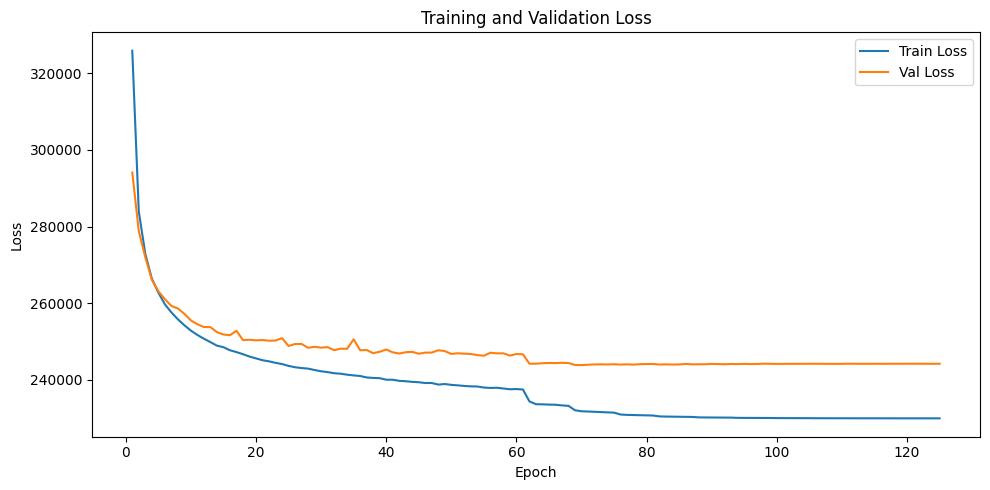

In [47]:
plot_loss_curves(train_losses, val_losses)

### Compute Centroids and Visualize Interpolation

In [ ]:
mus, labels = encode_train_images(vae_model, train_loader)
centroids = compute_centroids(mus, labels)
umap_visual(mus, labels)

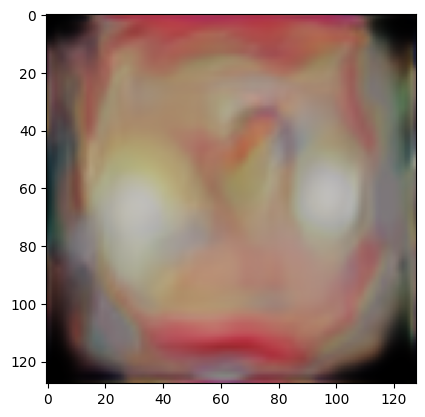

In [59]:
centroid_a = centroids[0]
centroid_b = centroids[5]
z = interpolate_centroids(centroid_a, centroid_b, 0.5)
combined_img = generate_combined_img(vae_model, z)
plt.imshow(combined_img)
plt.show()

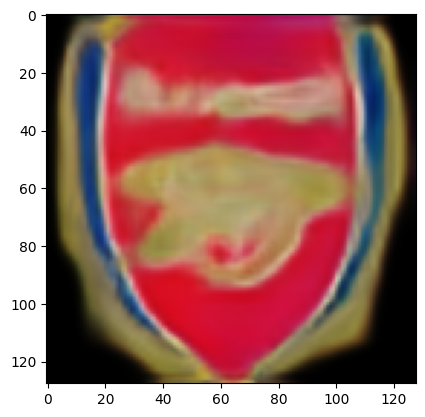

In [60]:
centroid_a = centroids[0]
centroid_b = centroids[5]
z = interpolate_centroids(centroid_a, centroid_b, 0.0)
combined_img = generate_combined_img(vae_model, z)
plt.imshow(combined_img)
plt.show()

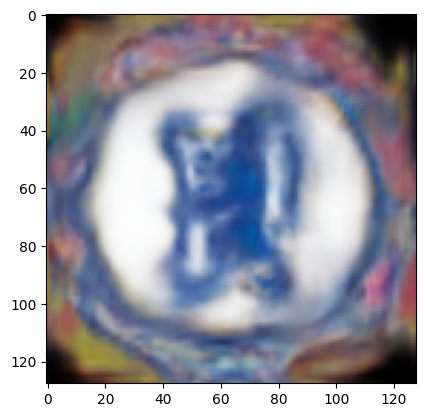

In [61]:
centroid_a = centroids[0]
centroid_b = centroids[5]
z = interpolate_centroids(centroid_a, centroid_b, 1.0)
combined_img = generate_combined_img(vae_model, z)
plt.imshow(combined_img)
plt.show()

In [62]:
print(centroids[0][:5])
print(centroids[1][:5])


[ 0.10774987 -0.16226383 -0.04835521  0.1010408   0.28104287]
[ 0.04823532 -0.3289842   0.12020998  0.08099174  0.17271636]


### Instantiate Model Type for GUI Testing

In [45]:
# Hyperparameters for Optimized Model
with open("optimized_results_checkpoints/best_hparams (1).json", "r") as f:
    best = json.load(f)

latent_dim = best["latent_dim"]
beta = best["beta"]
lr = best["lr"]
batch_size = best["batch_size"]

In [ ]:
# Hyperparameters for Large Model
with open("larger_model_results_checkpoints/best_hparams (2).json", "r") as f:
    best = json.load(f)

latent_dim = best["latent_dim"]
beta = best["beta"]
lr = best["lr"]
batch_size = best["batch_size"]

In [46]:
# Build data loaders if not done already
(train_paths, val_paths) = split_train_val(OUTPUT_PATH, 0.2)
(train_loader, val_loader) = build_dataloaders(train_paths, val_paths, batch_size)

In [49]:
# Set model variables and load correct weight parameters
gui_vae_model = VAE(IMG_SIZE, latent_dim)
# gui_vae_model.load_state_dict(torch.load("optimized_results_checkpoints/model_weights_249.pt")) # For model on GPU
gui_vae_model.load_state_dict(torch.load("optimized_results_checkpoints/model_weights_249.pt", map_location=torch.device('cpu'))) # For model on CPU
# gui_vae_model = VAE_large(IMG_SIZE, latent_dim)
# gui_vae_model.load_state_dict(torch.load("large_model_results_checkpoints/model_weights_124.pt"))
# gui_vae_model.load_state_dict(torch.load("large_model_results_checkpoints/model_weights_124.pt", map_location=torch.device('cpu)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gui_vae_model = gui_vae_model.to(device)
gui_vae_model.eval()

VAE(
  (encoder): Encoder(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (activation): ReLU()
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (mu): Linear(in_features=16384, out_features=512, bias=True)
    (log_var): Linear(in_features=16384, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (relu): ReLU()
    (sigmoid): Sigmoid()
    (linear1): Linear(in_features=512, out_features=16384, bias=True)
    (up_sample1): Upsample(scale_factor=2.0, mode='bilinear')
    (conv1): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (up_sample2): Upsample(scale_factor=2.0, mode='bilinear')
    (conv2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (up_sample3): Upsa

In [50]:
mus, labels = encode_train_images(gui_vae_model, train_loader)
centroids = compute_centroids(mus, labels)

/Users/spencerbuehlman/Desktop/gen_AI_EPL_Badge_Generator_Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:433: UserWarning: Got pickle error when attempting to start a worker Process. This might be because the worker Process arguments are not picklable. Python 3.14+ changed the multiprocessing start method in non-Mac POSIX platforms to 'forkserver', which requires the worker Process arguments to be picklable. You can also try multiprocessing.set_start_method('fork').
  return _MultiProcessingDataLoaderIter(self)


AttributeError: Can't get local object 'build_dataloaders.<locals>.eplDataset'

In [87]:
print(centroids[0][:5])
print(centroids[1][:5])

[ 0.08546457  0.31202474 -2.5495188   0.4862881   0.611097  ]
[ 0.41988462 -0.08198132 -1.125296    0.8725626  -1.2134113 ]


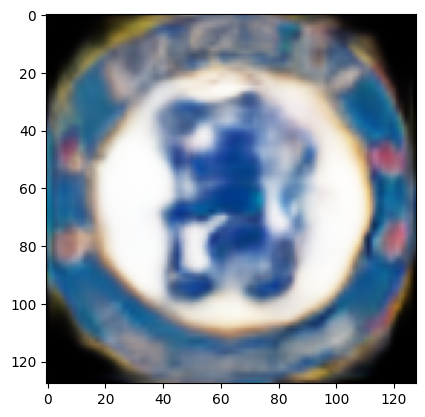

In [91]:
centroid_a = centroids[0]
centroid_b = centroids[5]
z = interpolate_centroids(centroid_a, centroid_b, 1.0)
combined_img = generate_combined_img(gui_vae_model, z)
plt.imshow(combined_img)
plt.show()

In [93]:
team_names = get_team_name_mapping(OUTPUT_PATH)
team_list = list(team_names.keys())

### GUI Gradio Interface

In [94]:
demo = gr.Interface(
    fn=generate_fusion_gradio,
    inputs=[
        gr.Dropdown(choices=team_list, label="Team A"),
        gr.Dropdown(choices=team_list, label="Team B"),
        gr.Slider(minimum=0, maximum=1, value=0.5, label="Blend (0=Team A, 1=Team B)")
    ],
    outputs=gr.Image(label="Fused Logo"),
    title="EPL Logo Fusion"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://702122f054e9e3e971.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
